In [37]:
import numpy as np 
import pandas as pd 

In [38]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [40]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [41]:
pd.DataFrame(df.isnull().sum())

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [42]:
df.duplicated().sum()

np.int64(3854)

In [43]:
df.drop_duplicates(keep = 'first' , inplace = True , ignore_index = True)

In [44]:
df.duplicated().sum()

np.int64(0)

# VISUALIZATION

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

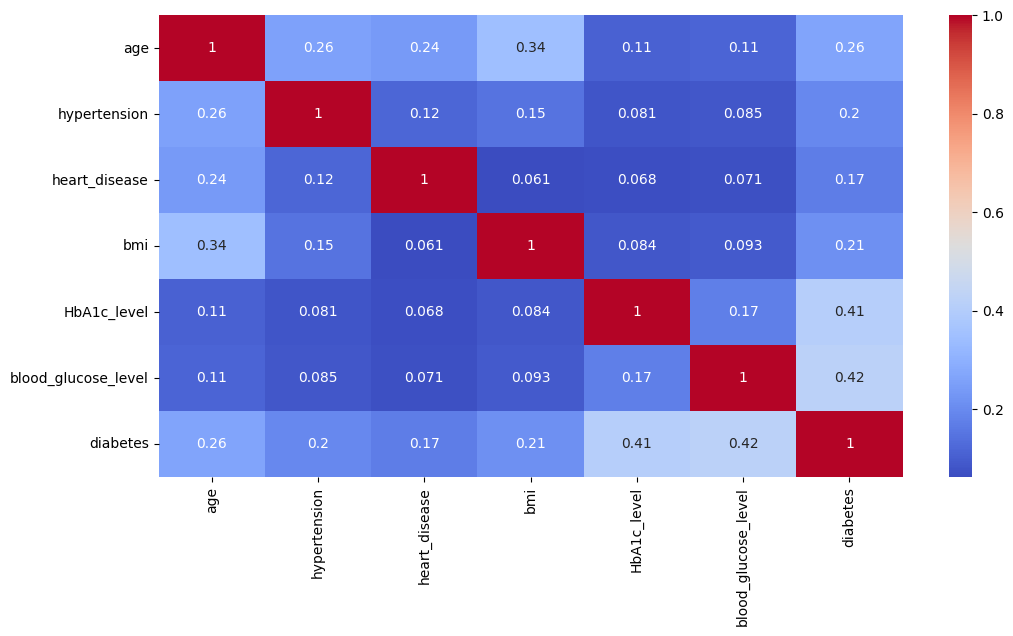

In [46]:
plt.figure(figsize = (12 , 6))
sns.heatmap(data = df.corr(numeric_only = True) , annot = True , cmap = 'coolwarm')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

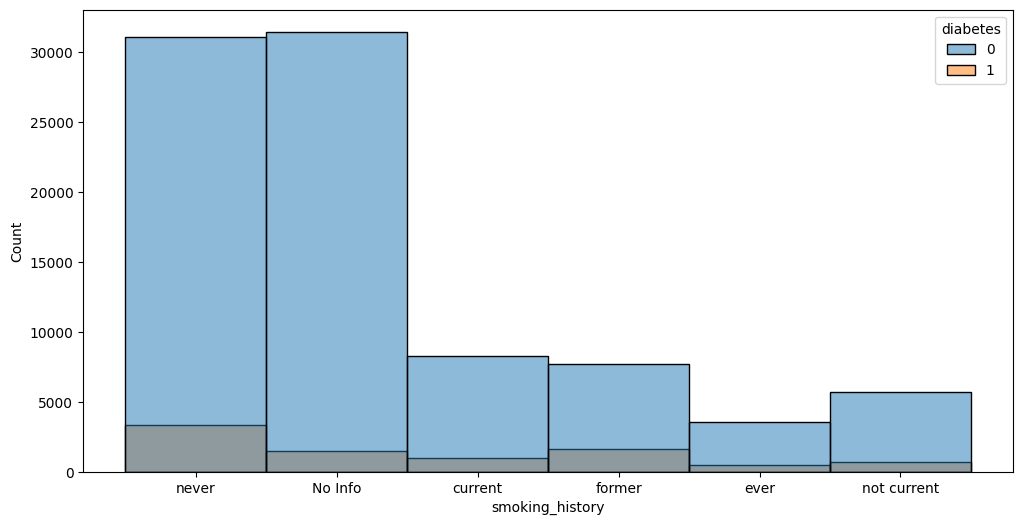

In [47]:
plt.figure(figsize = (12 , 6))
sns.histplot(data = df , x = 'smoking_history' , hue = 'diabetes')
plt.show

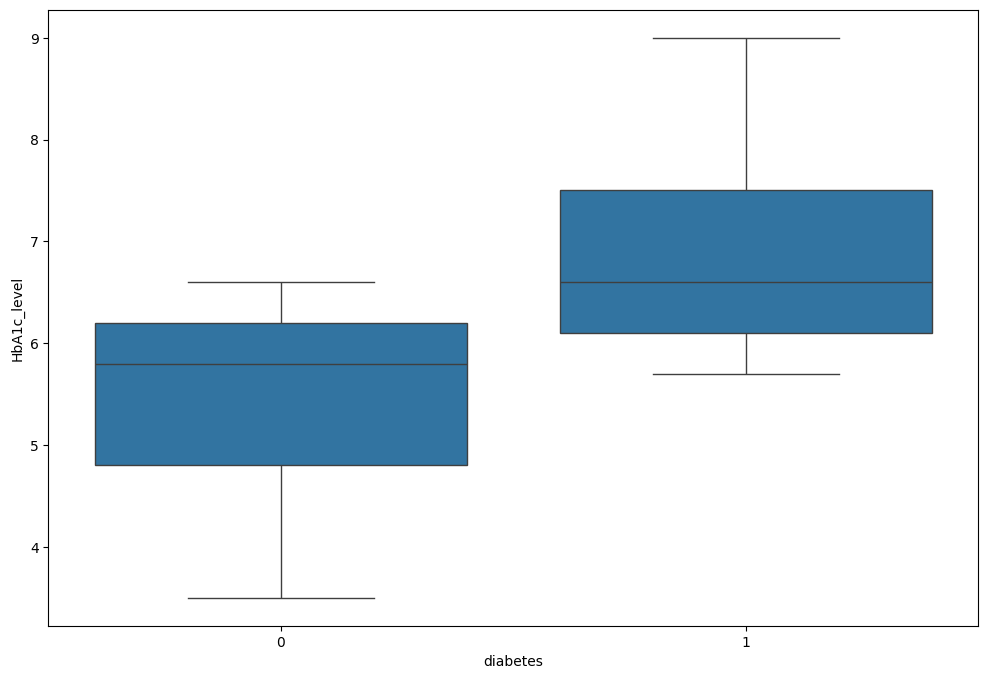

In [48]:
plt.figure(figsize = (12 , 8))
sns.boxplot(data = df , x = 'diabetes' , y = 'HbA1c_level')
plt.show() # HbA1c_level ve diabetes arasında bağlantı var 

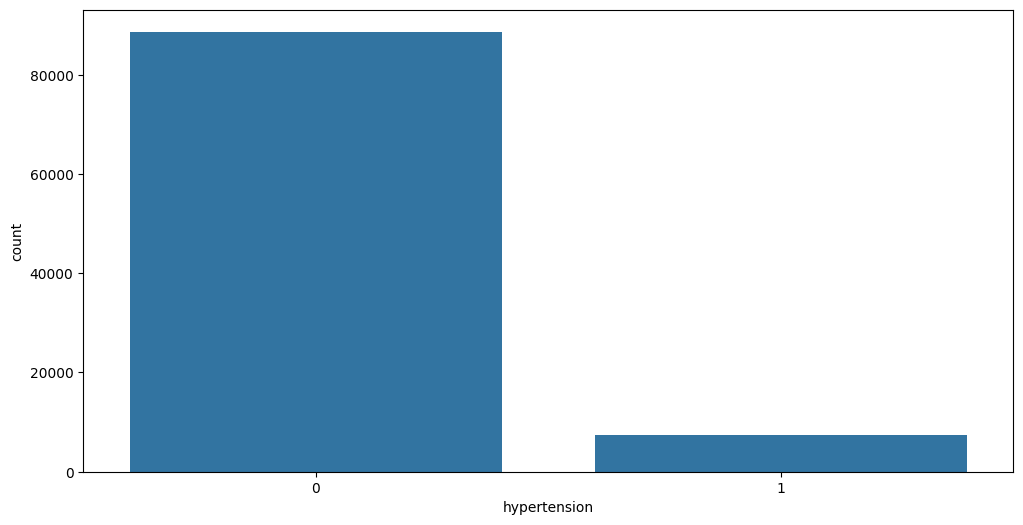

In [49]:
plt.figure(figsize = (12 , 6))
sns.countplot(data = df , x = 'hypertension')
plt.show()

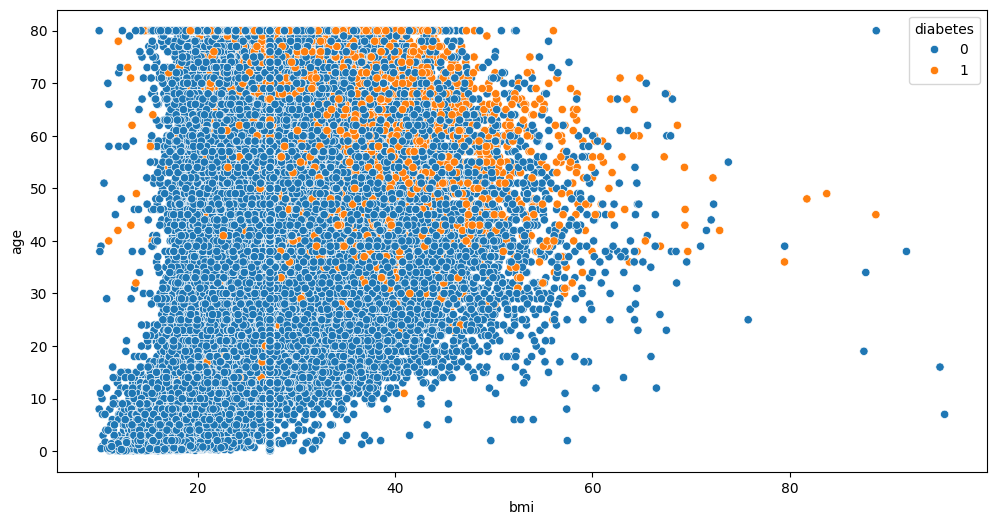

In [50]:
plt.figure(figsize = (12 , 6))
sns.scatterplot(data = df , x ='bmi' , y = 'age' , hue = 'diabetes')
plt.show()

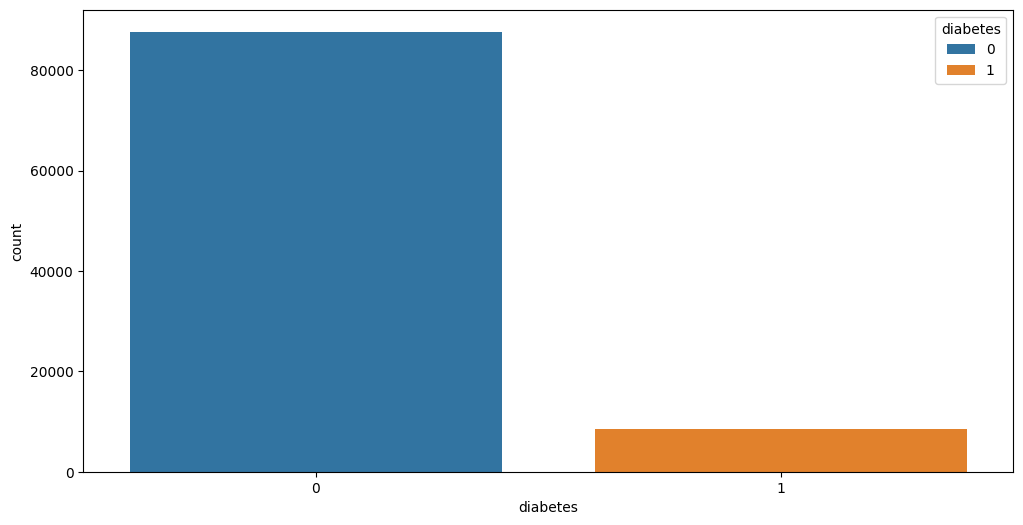

In [51]:
plt.figure(figsize = (12 , 6))
sns.countplot(data = df , hue = 'diabetes' , x = 'diabetes')
plt.show()

In [52]:
# Daha dengeli hale getirdik.

df1 = df[df['diabetes'] == 1]
df0 = df[df['diabetes'] == 0]

count_1 = len(df1)

df_0_sampled = df0.sample(n = count_1 + 1500, random_state=42)


df = pd.concat([df1, df_0_sampled])


df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df['diabetes'].value_counts())

diabetes
0    9982
1    8482
Name: count, dtype: int64


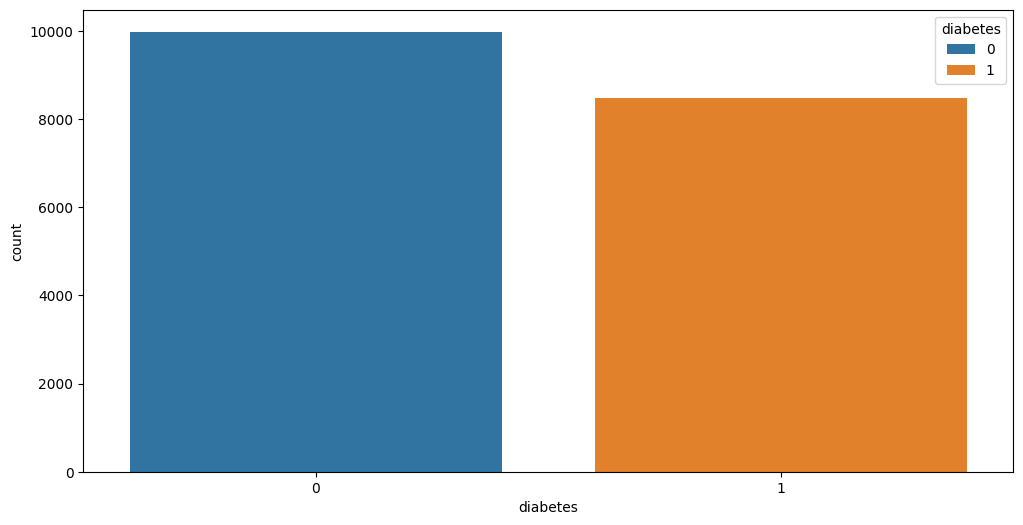

In [53]:
plt.figure(figsize = (12 , 6))
sns.countplot(data = df , hue = 'diabetes' , x = 'diabetes')
plt.show()

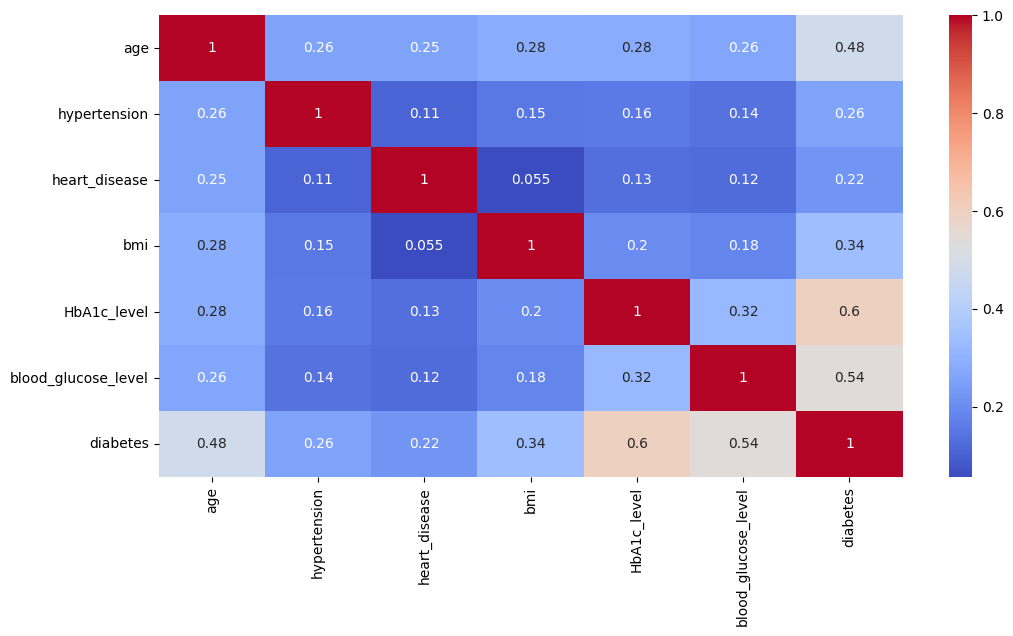

In [54]:
plt.figure(figsize = (12 , 6))
sns.heatmap(data = df.corr(numeric_only = True) , annot = True , cmap = 'coolwarm')
plt.show()

# DATA OPERATIONS

In [55]:
X = df.drop(columns = 'diabetes')
y = df['diabetes']


In [56]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 ,random_state = 42)

In [57]:

mapping_dict = {
    'never': 0,               # Hiç içmeyenler en düşük risk
    'former': 1,              # Geçmişte içenler
    'ever': 1,                # Geçmişte içenler
    'not current': 1,         # Geçmişte içenler
    'current': 2,             # Şu an içenler en yüksek risk
    'No Info': -1             # Bilgi olmayanları modelin ayırabilmesi için -1
}

X_train['smoking_history_mapped'] = X_train['smoking_history'].map(mapping_dict)
X_test['smoking_history_mapped'] = X_test['smoking_history'].map(mapping_dict)

In [58]:
X_train.drop(columns = 'smoking_history' , inplace = True)
X_test.drop(columns = 'smoking_history' , inplace = True)

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer([
    ('one-hot' , OneHotEncoder(drop = 'first' , sparse_output = False) , ['gender'])
], remainder = 'passthrough' , verbose_feature_names_out = False)

transformer.set_output(transform = 'pandas')

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [60]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy = 'auto' , random_state = 42)

X_train_smote , y_train_smote = smote.fit_resample(X_train_transformed , y_train)

print(f'Onceki Hali : {y_train.value_counts()}')
print(f'Sonraki Hali : {y_train_smote.value_counts()}')

Onceki Hali : diabetes
0    8009
1    6762
Name: count, dtype: int64
Sonraki Hali : diabetes
0    8009
1    8009
Name: count, dtype: int64


# MODEL TRAINING 

In [61]:
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [62]:
models = {
    'RandomForestC' : RandomForestClassifier(),
    'AdaBoostC' : AdaBoostClassifier(),
    'GradientBoostingC' : GradientBoostingClassifier(),
    'XGBoostC' : XGBClassifier(),
    'LightGBM' : LGBMClassifier(verbose = -1)
}

In [63]:
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
def calculate_metrics(y_test , y_pred) : 
    ac = accuracy_score(y_test , y_pred)
    cr = classification_report(y_test , y_pred)
    cm = confusion_matrix(y_test , y_pred)

    return ac , cr , cm

In [64]:
results = []

for name , model in models.items() : 
    model.fit(X_train_smote , y_train_smote)

    y_pred = model.predict(X_test_transformed)

    ac , cr , cm = calculate_metrics(y_test , y_pred)

    results.append({
        'Name' : name , 
        'Accuracy' : ac
    })

results_df = pd.DataFrame(results)


results_df

,Name,Accuracy
0,RandomForestC,0.898998
1,AdaBoostC,0.894666
2,GradientBoostingC,0.908475
3,XGBoostC,0.899269
4,LightGBM,0.901706


# HYPERPARAMETER TUNING

In [65]:
params = {
    'learning_rate' : [0.01 , 0.1 , 0.2] ,
    'n_estimators' : [100 , 200 , 300] , 
    'max_depth' : [3 , 5 , 6 , 8 ,10 ] , 
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],    
    'min_samples_leaf': [1, 2, 4]  
}

In [66]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

random = RandomizedSearchCV(
    estimator = GradientBoostingClassifier(),
    param_distributions = params ,
    cv = StratifiedKFold(n_splits = 5 , random_state = 42 , shuffle = True),
    n_jobs = -1 , 
    scoring = 'accuracy'
    )

In [67]:
random.fit(X_train_smote , y_train_smote)

y_pred = random.predict(X_test_transformed)

ac , cr , cm = calculate_metrics(y_test , y_pred)

print('Accuracy Score : ' , ac)
print('Classification Report : \n' , cr)
print('\n Confusion Matrix \n' , cm)
print('\n\n Best Params  : ', random.best_params_)

Accuracy Score :  0.9046845383157325
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.88      0.91      1973
           1       0.87      0.93      0.90      1720

    accuracy                           0.90      3693
   macro avg       0.90      0.91      0.90      3693
weighted avg       0.91      0.90      0.90      3693


 Confusion Matrix 
 [[1743  230]
 [ 122 1598]]


 Best Params  :  {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 8, 'learning_rate': 0.01}
